# Norwegian Wind Station Analysis (2021–2025)

Data from three coastal stations in northern Norway, sourced from MET Norway (CC BY 4.0):
- **Hekkingen Fyr** (SN88690)
- **Fakken** (SN90760)
- **Tromsø - Langnes** (SN90490)

Hourly observations of mean wind speed, max mean wind speed, max gust, and wind direction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "/Users/siche9897/Github/c-klima-data"

dfs = []
for year in range(2021, 2026):
    df = pd.read_csv(
        f"{DATA_DIR}/wind-{year}.csv",
        sep=";",
        skipfooter=1,   # skip the attribution row
        engine="python",
        encoding="utf-8",
    )
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

# Rename columns to short, clean names
df.columns = ["station_name", "station_id", "time_raw",
               "max_mean_wind", "max_gust", "wind_dir", "mean_wind"]

# Parse Norwegian-format timestamps: DD.MM.YYYY HH:MM
df["time"] = pd.to_datetime(df["time_raw"], format="%d.%m.%Y %H:%M")
df = df.drop(columns=["time_raw"])

# Coerce numeric columns (some rows may have missing markers)
for col in ["max_mean_wind", "max_gust", "wind_dir", "mean_wind"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values(["station_name", "time"]).reset_index(drop=True)
print(f"Total rows: {len(df):,}")
print(f"Date range: {df['time'].min()} → {df['time'].max()}")
print(f"\nStations:\n{df.groupby('station_name')['station_id'].first().to_string()}")
df.head()

Total rows: 130,588
Date range: 2021-01-01 01:00:00 → 2026-01-01 00:00:00

Stations:
station_name
Fakken              SN90760
Hekkingen Fyr       SN88690
Tromsø - Langnes    SN90490


,station_name,station_id,max_mean_wind,max_gust,wind_dir,mean_wind,time
0,Fakken,SN90760,19.6,23.8,136.0,18.4,2021-01-01 01:00:00
1,Fakken,SN90760,20.3,24.1,138.0,18.7,2021-01-01 02:00:00
2,Fakken,SN90760,18.8,22.7,140.0,18.8,2021-01-01 03:00:00
3,Fakken,SN90760,18.7,22.5,144.0,17.6,2021-01-01 04:00:00
4,Fakken,SN90760,19.6,22.6,140.0,17.2,2021-01-01 05:00:00


## 1. Summary Statistics

In [2]:
summary = (
    df.groupby("station_name")[["mean_wind", "max_mean_wind", "max_gust"]]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)
summary.columns = ["_".join(c) for c in summary.columns]

# Pretty display
for station, row in summary.iterrows():
    print(f"\n{'='*55}")
    print(f"  {station}")
    print(f"{'='*55}")
    print(f"  Observations      : {int(row['mean_wind_count']):,}")
    print(f"  Mean wind  (m/s)  : mean={row['mean_wind_mean']:.2f}, std={row['mean_wind_std']:.2f}, max={row['mean_wind_max']:.1f}")
    print(f"  Max mean   (m/s)  : mean={row['max_mean_wind_mean']:.2f}, std={row['max_mean_wind_std']:.2f}, max={row['max_mean_wind_max']:.1f}")
    print(f"  Max gust   (m/s)  : mean={row['max_gust_mean']:.2f}, std={row['max_gust_std']:.2f}, max={row['max_gust_max']:.1f}")


  Fakken
  Observations      : 43,793
  Mean wind  (m/s)  : mean=8.12, std=4.84, max=35.3
  Max mean   (m/s)  : mean=9.61, std=5.05, max=35.5
  Max gust   (m/s)  : mean=12.00, std=6.35, max=51.7

  Hekkingen Fyr
  Observations      : 43,007
  Mean wind  (m/s)  : mean=6.25, std=4.10, max=30.8
  Max mean   (m/s)  : mean=7.65, std=4.34, max=34.3
  Max gust   (m/s)  : mean=10.08, std=5.81, max=51.9

  Tromsø - Langnes
  Observations      : 43,658
  Mean wind  (m/s)  : mean=4.52, std=3.15, max=23.1
  Max mean   (m/s)  : mean=5.63, std=3.37, max=23.7
  Max gust   (m/s)  : mean=7.32, std=4.23, max=31.9


## 2. Monthly Mean Wind Speed (2021–2025)

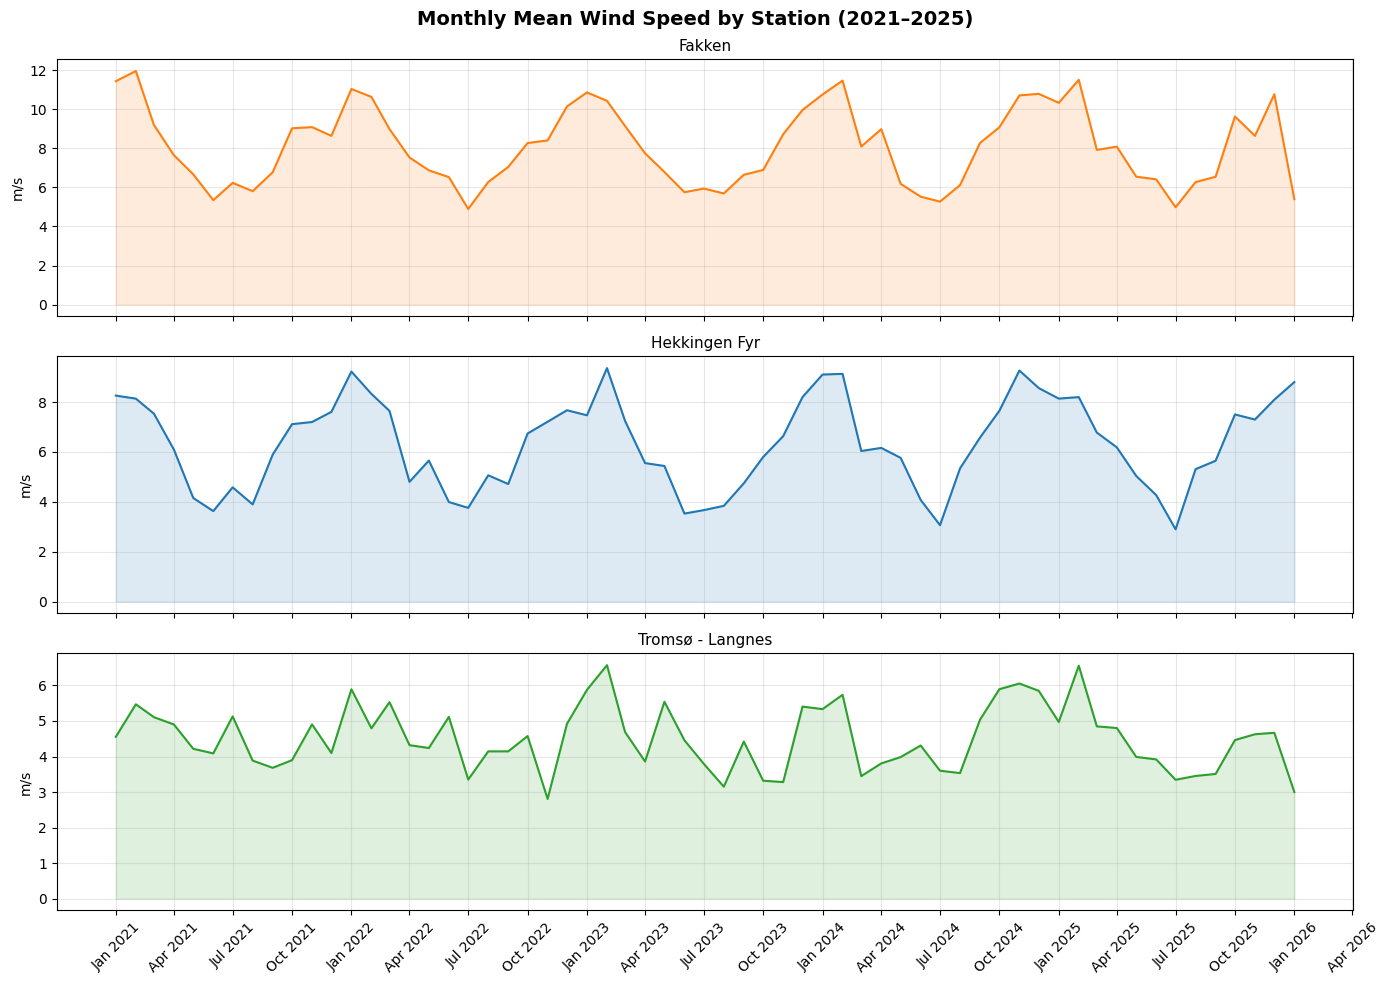

In [3]:
df["year_month"] = df["time"].dt.to_period("M")
monthly = df.groupby(["station_name", "year_month"])["mean_wind"].mean().reset_index()
monthly["date"] = monthly["year_month"].dt.to_timestamp()

stations = df["station_name"].unique()
colors = {"Hekkingen Fyr": "#1f77b4", "Fakken": "#ff7f0e", "Tromsø - Langnes": "#2ca02c"}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Monthly Mean Wind Speed by Station (2021–2025)", fontsize=14, fontweight="bold")

for ax, station in zip(axes, sorted(stations)):
    sub = monthly[monthly["station_name"] == station]
    ax.plot(sub["date"], sub["mean_wind"], color=colors.get(station, "steelblue"), linewidth=1.5)
    ax.fill_between(sub["date"], sub["mean_wind"], alpha=0.15, color=colors.get(station, "steelblue"))
    ax.set_ylabel("m/s")
    ax.set_title(station, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Seasonal Wind Pattern (Average by Month of Year)

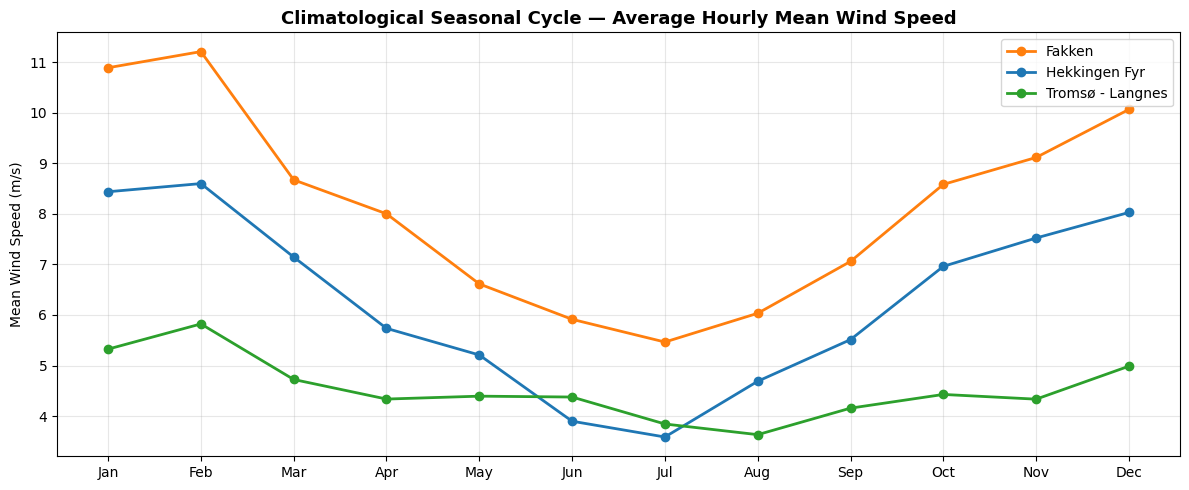

In [4]:
df["month"] = df["time"].dt.month
seasonal = df.groupby(["station_name", "month"])["mean_wind"].mean().reset_index()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
for station in sorted(stations):
    sub = seasonal[seasonal["station_name"] == station].sort_values("month")
    ax.plot(sub["month"], sub["mean_wind"], marker="o", linewidth=2,
            color=colors.get(station), label=station)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel("Mean Wind Speed (m/s)")
ax.set_title("Climatological Seasonal Cycle — Average Hourly Mean Wind Speed", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Wind Speed Distribution (Box Plot)

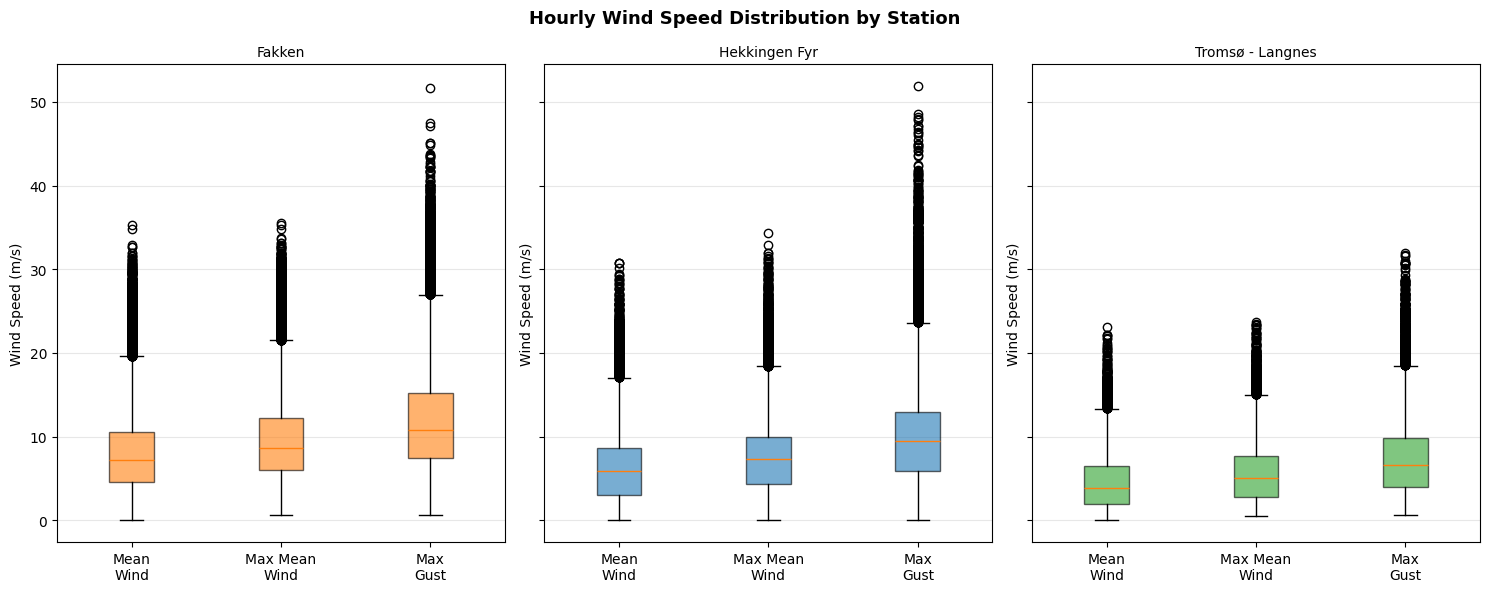

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
fig.suptitle("Hourly Wind Speed Distribution by Station", fontsize=13, fontweight="bold")

for ax, station in zip(axes, sorted(stations)):
    sub = df[df["station_name"] == station]
    data = [
        sub["mean_wind"].dropna().values,
        sub["max_mean_wind"].dropna().values,
        sub["max_gust"].dropna().values,
    ]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    labels=["Mean\nWind", "Max Mean\nWind", "Max\nGust"])
    col = colors.get(station, "steelblue")
    for patch in bp["boxes"]:
        patch.set_facecolor(col)
        patch.set_alpha(0.6)
    ax.set_title(station, fontsize=10)
    ax.set_ylabel("Wind Speed (m/s)")
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 5. Wind Rose — Prevailing Wind Direction by Station

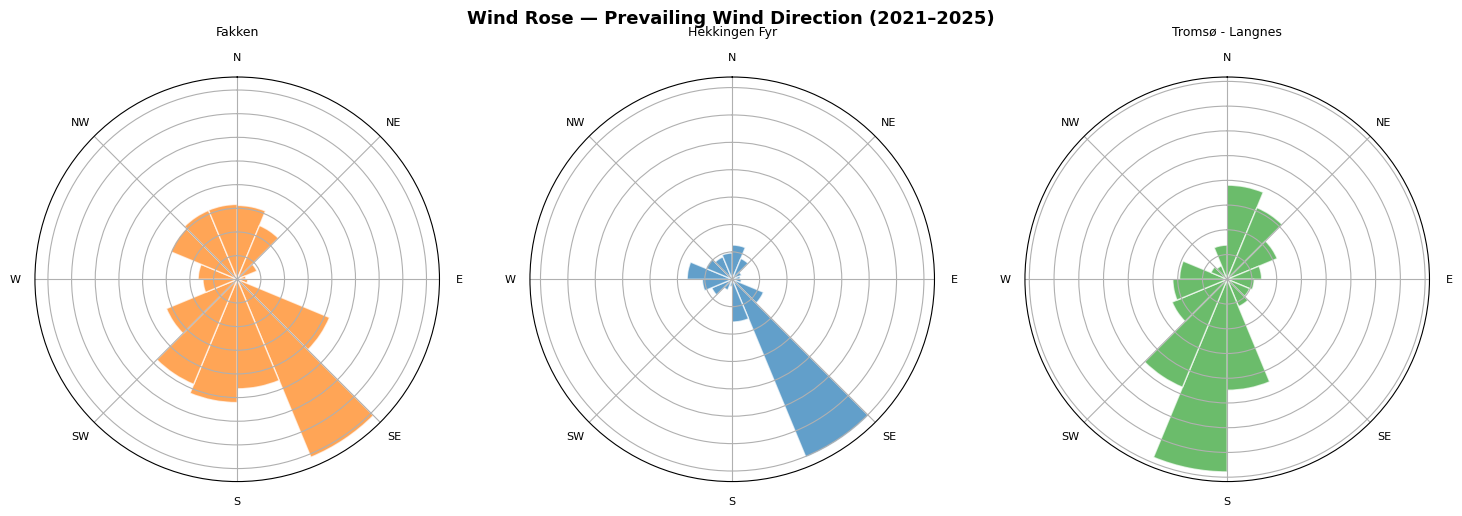

In [6]:
n_bins = 16
bin_edges = np.linspace(0, 360, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = np.deg2rad(360 / n_bins)

fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         subplot_kw={"projection": "polar"})
fig.suptitle("Wind Rose — Prevailing Wind Direction (2021–2025)", fontsize=13, fontweight="bold")

for ax, station in zip(axes, sorted(stations)):
    sub = df[df["station_name"] == station].dropna(subset=["wind_dir"])
    counts, _ = np.histogram(sub["wind_dir"], bins=bin_edges)
    freq = counts / counts.sum()
    # Polar bar: 0° = North, clockwise → convert
    theta = np.deg2rad(bin_centers)
    bars = ax.bar(theta, freq, width=width, bottom=0,
                  color=colors.get(station, "steelblue"), alpha=0.7, edgecolor="white")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(station, fontsize=9, pad=12)
    ax.set_yticklabels([])
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"], fontsize=8)

plt.tight_layout()
plt.show()

## 6. Annual Statistics — Year-over-Year Comparison

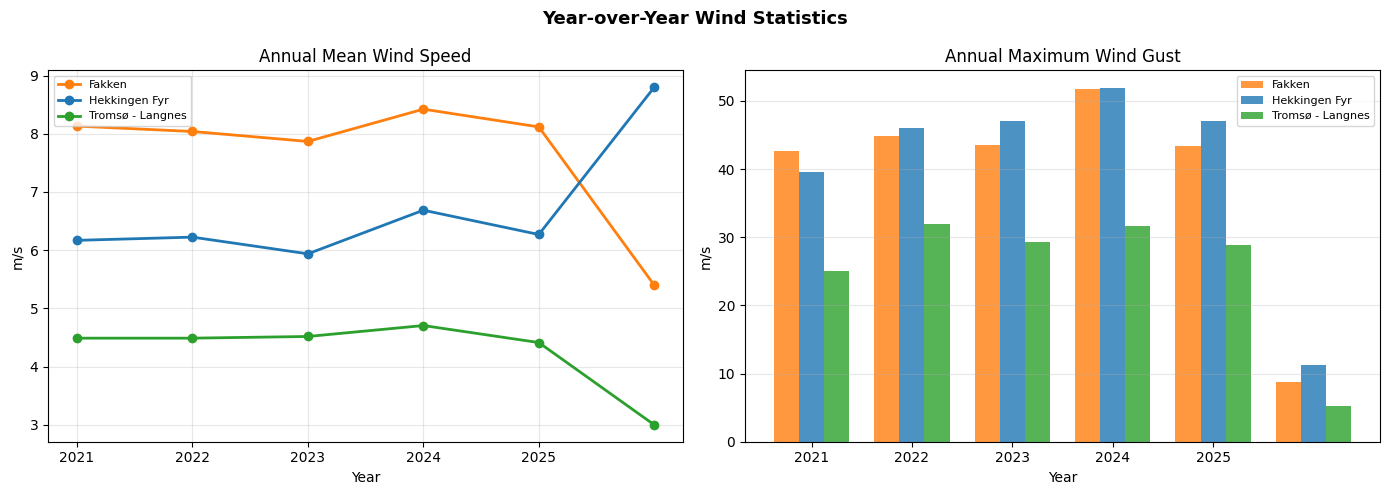

In [7]:
df["year"] = df["time"].dt.year
annual = df.groupby(["station_name", "year"])["mean_wind"].mean().reset_index()
annual_gust = df.groupby(["station_name", "year"])["max_gust"].max().reset_index()
annual = annual.merge(annual_gust, on=["station_name", "year"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Year-over-Year Wind Statistics", fontsize=13, fontweight="bold")

# Mean wind per year
for station in sorted(stations):
    sub = annual[annual["station_name"] == station]
    ax1.plot(sub["year"], sub["mean_wind"], marker="o", linewidth=2,
             color=colors.get(station), label=station)
ax1.set_title("Annual Mean Wind Speed")
ax1.set_ylabel("m/s")
ax1.set_xlabel("Year")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(2021, 2026))

# Max gust per year
for station in sorted(stations):
    sub = annual[annual["station_name"] == station]
    ax2.bar(
        np.array(sub["year"]) + sorted(stations).index(station) * 0.25 - 0.25,
        sub["max_gust"], width=0.25, color=colors.get(station), alpha=0.8,
        label=station
    )
ax2.set_title("Annual Maximum Wind Gust")
ax2.set_ylabel("m/s")
ax2.set_xlabel("Year")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_xticks(range(2021, 2026))

plt.tight_layout()
plt.show()

## 7. Diurnal Cycle — Average Wind Speed by Hour of Day

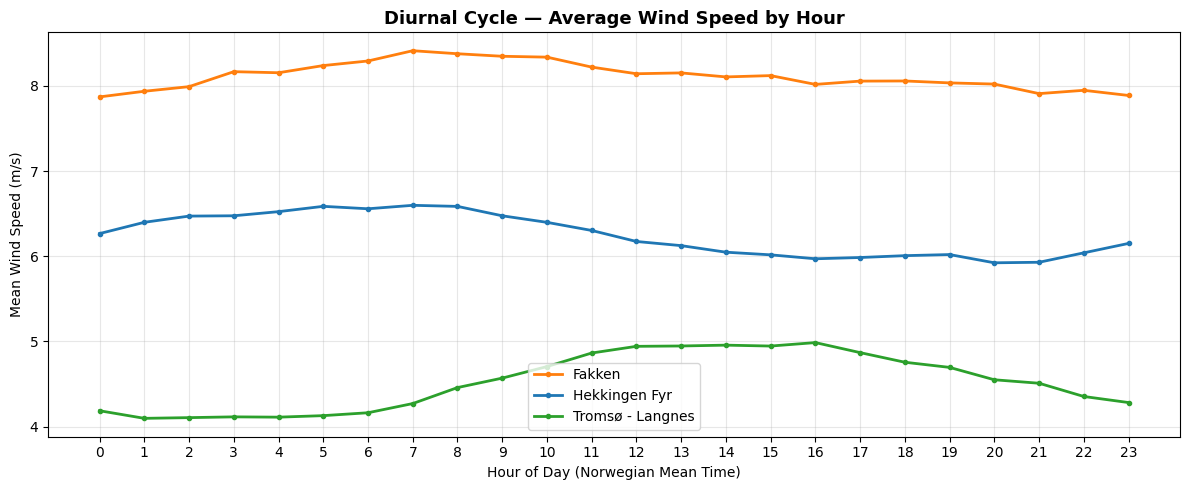

In [8]:
df["hour"] = df["time"].dt.hour
diurnal = df.groupby(["station_name", "hour"])["mean_wind"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for station in sorted(stations):
    sub = diurnal[diurnal["station_name"] == station].sort_values("hour")
    ax.plot(sub["hour"], sub["mean_wind"], marker=".", linewidth=2,
            color=colors.get(station), label=station)

ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of Day (Norwegian Mean Time)")
ax.set_ylabel("Mean Wind Speed (m/s)")
ax.set_title("Diurnal Cycle — Average Wind Speed by Hour", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Narrative Summary

In [9]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"  Source     : MET Norway (CC BY 4.0)")
print(f"  Period     : {df['time'].min().date()} → {df['time'].max().date()}")
print(f"  Resolution : Hourly")
print(f"  Total obs  : {len(df):,}")
print(f"  Missing    : mean_wind={df['mean_wind'].isna().sum():,}  "
      f"max_gust={df['max_gust'].isna().sum():,}  "
      f"wind_dir={df['wind_dir'].isna().sum():,}")

print("\n" + "=" * 60)
print("PER-STATION HIGHLIGHTS")
print("=" * 60)

for station in sorted(stations):
    sub = df[df["station_name"] == station]
    mean_spd = sub["mean_wind"].mean()
    max_g = sub["max_gust"].max()
    max_g_time = sub.loc[sub["max_gust"].idxmax(), "time"]
    top_dir = sub["wind_dir"].dropna().round(-1).mode()[0]
    print(f"\n  {station}")
    print(f"    5-year mean wind    : {mean_spd:.2f} m/s")
    print(f"    All-time max gust   : {max_g:.1f} m/s  ({max_g_time:%Y-%m-%d %H:%M})")
    print(f"    Most frequent dir   : ~{int(top_dir)}°")

print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)
ranked = df.groupby("station_name")["mean_wind"].mean().sort_values(ascending=False)
windiest = ranked.index[0]
calmest  = ranked.index[-1]
print(f"  Windiest station    : {windiest} ({ranked[windiest]:.2f} m/s)")
print(f"  Calmest station     : {calmest}  ({ranked[calmest]:.2f} m/s)")
print(f"  Peak season         : winter months (Nov–Feb) across all stations")
print(f"  Diurnal signal      : weak (coastal exposure dominates thermal forcing)")

DATASET SUMMARY
  Source     : MET Norway (CC BY 4.0)
  Period     : 2021-01-01 → 2026-01-01
  Resolution : Hourly
  Total obs  : 130,588
  Missing    : mean_wind=130  max_gust=0  wind_dir=83

PER-STATION HIGHLIGHTS

  Fakken
    5-year mean wind    : 8.12 m/s
    All-time max gust   : 51.7 m/s  (2024-01-29 16:00)
    Most frequent dir   : ~140°

  Hekkingen Fyr
    5-year mean wind    : 6.25 m/s
    All-time max gust   : 51.9 m/s  (2024-01-29 14:00)
    Most frequent dir   : ~140°

  Tromsø - Langnes
    5-year mean wind    : 4.52 m/s
    All-time max gust   : 31.9 m/s  (2022-02-27 15:00)
    Most frequent dir   : ~180°

KEY FINDINGS
  Windiest station    : Fakken (8.12 m/s)
  Calmest station     : Tromsø - Langnes  (4.52 m/s)
  Peak season         : winter months (Nov–Feb) across all stations
  Diurnal signal      : weak (coastal exposure dominates thermal forcing)
